In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import QuantLib as ql
import re
from scipy.stats import norm
from scipy.optimize import brentq

In [43]:
def to_py_date(date: ql.Date) -> datetime:
    return datetime(date.year(), date.month(), date.dayOfMonth())

def to_ql_date(date: datetime) -> ql.Date:
    return ql.Date(date.day, date.month, date.year)

day_count = ql.Actual365Fixed()
def year_frac(start: datetime, maturity: datetime) -> float:
    return day_count.yearFraction(to_ql_date(start), to_ql_date(maturity))

In [44]:
asof_dt = datetime(2026, 7, 17)
asof_ql_dt = to_ql_date(asof_dt)

In [45]:
usdjpy_fwd = (
    pd.read_csv("usdjpy_fwd.csv")
    .assign(delivery_date=lambda d: pd.to_datetime(d["delivery_date"]))
)
usdjpy_spot = usdjpy_fwd.loc[lambda d: d["label"].eq("SPOT")].iloc[0]["outright"]
usdjpy_fwd

,label,delivery_date,outright
0,TOD,2026-07-17,162.450710
1,TOM,2026-07-21,162.402100
2,SPOT,2026-07-22,162.390000
3,SN,2026-07-23,162.377350
4,2W,2026-08-05,162.208500
5,3W,2026-08-12,162.119000
6,1M,2026-08-24,161.965150
7,2M,2026-09-24,161.559650
8,3M,2026-10-22,161.186500
9,4M,2026-11-24,160.754000


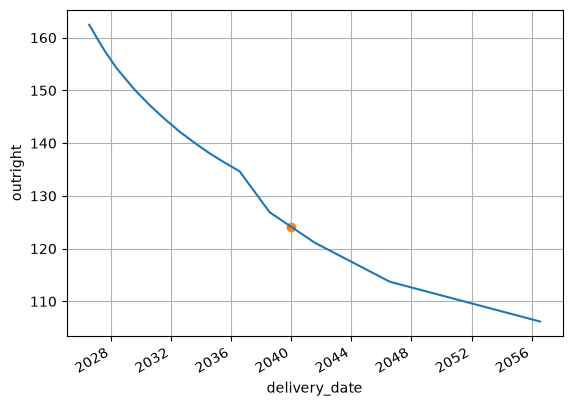

In [46]:
usd_calendar = ql.UnitedStates(ql.UnitedStates.Settlement)
jpy_calendar = ql.Japan()
calendar = ql.JointCalendar(
    usd_calendar,
    jpy_calendar,
    ql.JoinHolidays,
)

def interp_fwd(delivery_date: datetime) -> float:
    target = pd.Timestamp(delivery_date).date()

    x = usdjpy_fwd["delivery_date"].apply(lambda x: x.toordinal()).to_numpy()
    y = usdjpy_fwd["outright"].apply(np.log).to_numpy()
    xt = float(delivery_date.toordinal())

    return float(np.exp(np.interp(xt, x, y)))

usdjpy_fwd.plot(x="delivery_date", y="outright", legend=None, grid=True, ylabel="outright")

dd = datetime(2040, 1, 1)
plt.scatter([dd], [interp_fwd(dd)], c="C1")

plt.show()

<Axes: xlabel='delivery_date', ylabel='annualized hedging cost (%)'>

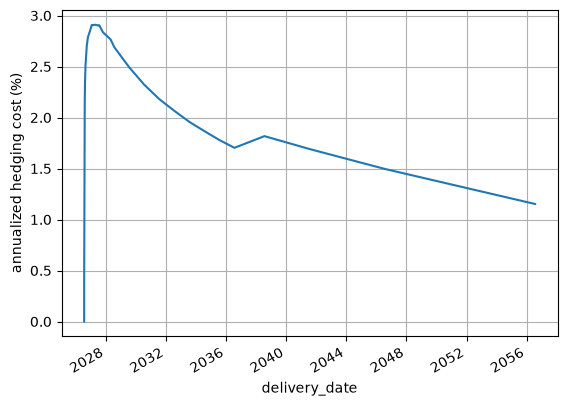

In [53]:
(
    usdjpy_fwd
    .loc[lambda d: d["delivery_date"] >= to_py_date(calendar.advance(asof_ql_dt, 2, ql.Days))]
    .assign(
        ann_hedge=lambda d:
        (usdjpy_spot - d["outright"])/ usdjpy_spot
        / d["delivery_date"].apply(lambda x: year_frac(asof_dt, x))
        * 100
    )
).plot(x="delivery_date", y="ann_hedge", legend=None, ylabel="annualized hedging cost (%)", grid=True)

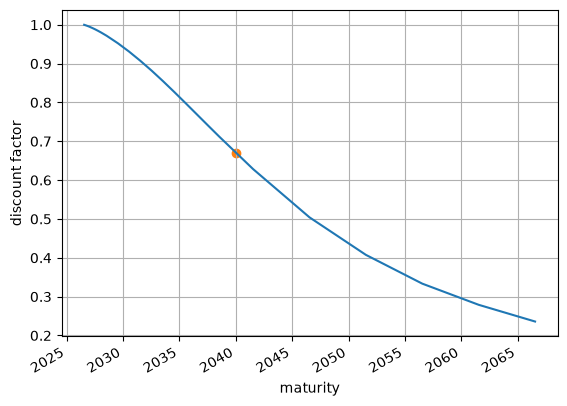

,tenor,ois,maturity,discount_factor
0,1D,0.97900,2026-07-21,0.999893
1,1W,0.97729,2026-07-24,0.999813
2,2W,0.97750,2026-07-31,0.999625
3,3W,0.97844,2026-08-07,0.999437
4,1M,0.97875,2026-08-17,0.999169
5,2M,0.97993,2026-09-17,0.998338
6,3M,0.99625,2026-10-19,0.997441
7,4M,1.02613,2026-11-17,0.996554
8,5M,1.04839,2026-12-17,0.995625
9,6M,1.07771,2027-01-19,0.994538


In [48]:
jpy_ois = (
    pd.read_csv("jpy_ois.csv")
    .assign(maturity=lambda d: pd.to_datetime(d["maturity"]))
)

def interp_df(deal_date: datetime) -> float:
    x = jpy_ois["maturity"].apply(lambda x: x.toordinal()).to_numpy()
    y = jpy_ois["discount_factor"].apply(np.log).to_numpy()
    return np.exp(np.interp(deal_date.toordinal(), x, y))

jpy_ois.plot(x="maturity", y="discount_factor", grid=True, legend=None, ylabel="discount factor")
plt.scatter([dd], [interp_df(dd)], c="C1")
plt.show()

jpy_ois

PRDCの年率クーポン$q_t$は（フロアとキャップを考えなければ）$c_f$と$c_d$を用いて次のように決められる
$$q_t = c_f {FX_t \over FX_0} - c_d$$
PVを評価するには$FX_t$にフォワード$F_t$を代入し割り引く（ここで$\alpha_t$はクーポン計算期間）
$$\sum_t PV[q_t] = \sum_t\left(c_f {F_t \over FX_0} - c_d \right)\alpha_t DF_t$$
理論価格がパーに等しいとする
$$DF_T+\sum_t PV[q_t]=1$$
$c_f$と$c_d$の関係は、
$$DF_T+c_f\sum_t{F_t\over FX_0}\alpha_t DF_t-c_d\sum_t\alpha_t DF_t=1$$
$c_d$を$c_f$について解く
$$c_d=c_f{\sum_t{F_t\over FX_0}\alpha_t DF_t\over\sum_t\alpha_t DF_t}-{1-DF_T\over\sum_t\alpha_t DF_t}$$
市場不変のシナリオで年率期待利回り$r$を求める

$FX_t=FX_0$として
$$
\begin{align}
r&=c_f-c_d\\
&=c_f-c_f{\sum_t{F_t\over FX_0}\alpha_t DF_t\over\sum_t\alpha_t DF_t}+{1-DF_T\over\sum_t\alpha_t DF_t}\\
&=c_f{\sum_t\alpha_t DF_t-\sum_t{F_t\over FX_0}\alpha_t DF_t\over\sum_t\alpha_t DF_t}+{1-DF_T\over\sum_t\alpha_t DF_t}\\
\end{align}
$$

In [49]:
maturity = calendar.advance(asof_ql_dt, 5, ql.Years)

schedule = ql.MakeSchedule(
    asof_ql_dt,
    maturity,
    ql.Period(6, ql.Months),
    calendar=calendar,
    convention=ql.ModifiedFollowing,
    terminalDateConvention=ql.ModifiedFollowing,
    rule=ql.DateGeneration.Forward,
    endOfMonth=False,
)

dates = [to_py_date(d) for d in schedule]
periods = list(zip(dates[:-1], dates[1:]))

df_T = interp_df(to_py_date(maturity))
df_coupons = sum(
    year_frac(start, end)
    * interp_df(end)
    for start, end in periods
)
df_fxs = sum(
    interp_fwd(end) / usdjpy_spot 
    * year_frac(start, end)
    * interp_df(end)
    for start, end in periods
)

print(f"annualized yield:\t{(df_coupons - df_fxs) / df_coupons:.3f} cf + {(1 - df_T) / df_coupons * 100:.3f} [%]")
print(f"swap rate:\t\t{jpy_ois[lambda d: d["maturity"].eq(to_py_date(maturity))].iloc[0]["ois"]:.3f} [%]")

annualized yield:	0.066 cf + 1.946 [%]
swap rate:		1.946 [%]


PRDCのクーポン$q_t$にフロア$K_\min$を設定する
$$
\begin{align}
q_t=c_f{FX_t\over FX_0}-c_d&\ge K_\min\\
{c_f\over FX_0}FX_t&\ge K_\min+c_d\\
FX_t&\ge{FX_0\over c_f}(K_\min+c_d)\\
\end{align}
$$
すなわちストライク${FX_0\over c_f}(K_\min+c_d)$のプットを$c_f\over FX_0$単位買えば良い

フォワード価格$F$、ストライク$K$のプット価格$V$は、
$$
\begin{align}
V&=DF_t(-F\Phi(-d_1)+K\Phi(-d_2))\\
d_1&={\ln{F\over K}+{1\over 2}\sigma^2 T\over\sigma\sqrt T}\\
d_2&=d_1-\sigma\sqrt{T}
\end{align}
$$
$K_\min=0$としてクーポン$q_t$のPVは、
$$
\begin{align}
PV[q_t]&=\left(c_f{F_t\over FX_0}-c_d+{c_f\over FX_0}(-F_t\Phi(-d_{1,t})+{FX_0\over c_f}c_d\Phi(-d_{2,t}))\right)\alpha_t DF_t\\
&=\left(c_f{F_t\over FX_0}-c_d-c_f{F_t\over FX_0}\Phi(-d_{1,t})+c_d\Phi(-d_{2,t})\right)\alpha_t DF_t\\
&=\left(c_f{F_t\over FX_0}(1-\Phi(-d_{1,t}))-c_d(1-\Phi(-d_{2,t}))\right)\alpha_t DF_t\\
&=\left(c_f{F_t\over FX_0}\Phi(d_{1,t})-c_d\Phi(d_{2,t})\right)\alpha_t DF_t\\
d_{1,t}&={\ln{c_f\over c_d}{F_t\over FX_0}+{1\over 2}\sigma^2t\over\sigma\sqrt{t}}\\
d_{2,t}&=d_{1,t}-\sigma\sqrt{t}
\end{align}
$$
理論価格がパーに等しいとすると、
$$
\begin{align}
DF_T+\sum_t PV[q_t]&=1\\
DF_T+\sum_t\left(c_f{F_t\over FX_0}\Phi(d_{1,t})-c_d\Phi(d_{2,t})\right)\alpha_t DF_t&=1\\
DF_T+c_f\sum_t{F_t\over FX_0}\Phi(d_{1,t})\alpha_t DF_t-c_d\sum_t\Phi(d_{2,t})\alpha_t DF_t&=1\\
\end{align}
$$
$c_d$を$c_f$について解く
$$
\begin{align}
c_d&=c_f{\sum_t{F_t\over FX_0}\Phi(d_{1,t})\alpha_t DF_t\over\sum_t\Phi(d_{2,t})\alpha_t DF_t}-{1-DF_T\over\sum_t\Phi(d_{2,t})\alpha_t DF_t}
\end{align}
$$
市場不変のシナリオで年率利回り$r$を求める

$FX_t=FX_0$として
$$
\begin{align}
r&=c_f-c_d\\
&=c_f-c_f{\sum_t{F_t\over FX_0}\Phi(d_{1,t})\alpha_t DF_t\over\sum_t\Phi(d_{2,t})\alpha_t DF_t}+{1-DF_T\over\sum_t\Phi(d_{2,t})\alpha_t DF_t}\\
&=c_f{\sum_t\Phi(d_{2,t})\alpha_t DF_t-\sum_t{F_t\over FX_0}\Phi(d_{1,t})\alpha_t DF_t\over\sum_t\Phi(d_{2,t})\alpha_t DF_t}+{1-DF_T\over\sum_t\Phi(d_{2,t})\alpha_t DF_t}\\
\end{align}
$$

In [54]:
vol = 0.07
cf = 0.15

def calc_phi_d1(cf: float, cd: float, vol: float, start: datetime, end: datetime) -> float:
    t = year_frac(start, end)
    return norm.cdf(
        (np.log(cf / cd * interp_fwd(end) / usdjpy_spot) + 0.5 * (vol ** 2) * t)
        / (vol * np.sqrt(t))
    )

def calc_phi_d2(cf: float, cd: float, vol: float, start: datetime, end: datetime) -> float:
    t = year_frac(start, end)
    return norm.cdf(
        (np.log(cf / cd * interp_fwd(end) / usdjpy_spot) - 0.5 * (vol ** 2) * t)
        / (vol * np.sqrt(t))
    )

def calc_coupon_pv(cf: float, cd: float):
    df_1_fxs = sum(
        interp_fwd(end) / usdjpy_spot
        * calc_phi_d1(cf, cd, vol, asof_dt, end)
        * year_frac(start, end)
        * interp_df(end)
        for start, end in periods
    )
    
    df_2_cpns = sum(
        calc_phi_d2(cf, cd, vol, asof_dt, end)
        * year_frac(start, end)
        * interp_df(end)
        for start, end in periods
    )

    return df_T + cf * df_1_fxs - cd * df_2_cpns - 1

cd = brentq(lambda x: calc_coupon_pv(cf, x), 0.01 ** 2, 1.0)

print(f"floored annualized yield:\t{(cf - cd) * 100:.3f} [%]")
print(f"unfloored annualized yield:\t{((df_coupons - df_fxs) / df_coupons * cf + (1 - df_T) / df_coupons) * 100:.3f} [%]")

floored annualized yield:	2.811 [%]
unfloored annualized yield:	2.932 [%]


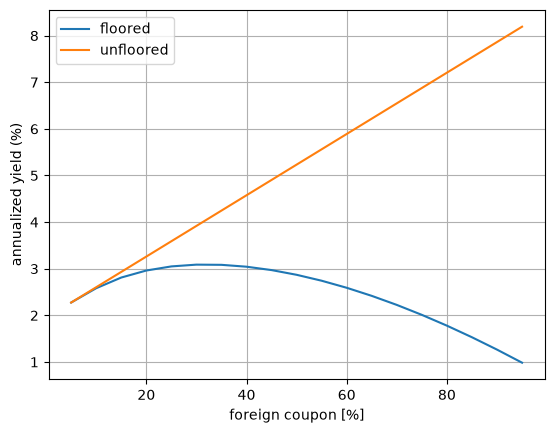

In [51]:
(
    pd.DataFrame([{"cf": i / 100} for i in np.arange(5, 100, 5)])
    .assign(
        cd=lambda d: d["cf"].apply(lambda x: brentq(lambda y: calc_coupon_pv(x, y), 0.01 ** 2, 1.0)),
        r=lambda d: (d["cf"] - d["cd"]) * 100,
        unfloored_r=lambda d: ((df_coupons - df_fxs) / df_coupons * d["cf"] + (1 - df_T) / df_coupons) * 100,
        cf=lambda d: d["cf"] * 100,
    )
).plot(
    x="cf", y=["r", "unfloored_r"],
    label=["floored", "unfloored"], xlabel="foreign coupon [%]", ylabel="annualized yield (%)", grid=True
)
plt.show()